In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import tensorflow as tf
import warnings
from sklearn.exceptions import ConvergenceWarning
from keras.models import Sequential
from keras.layers import Dense
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Dataset

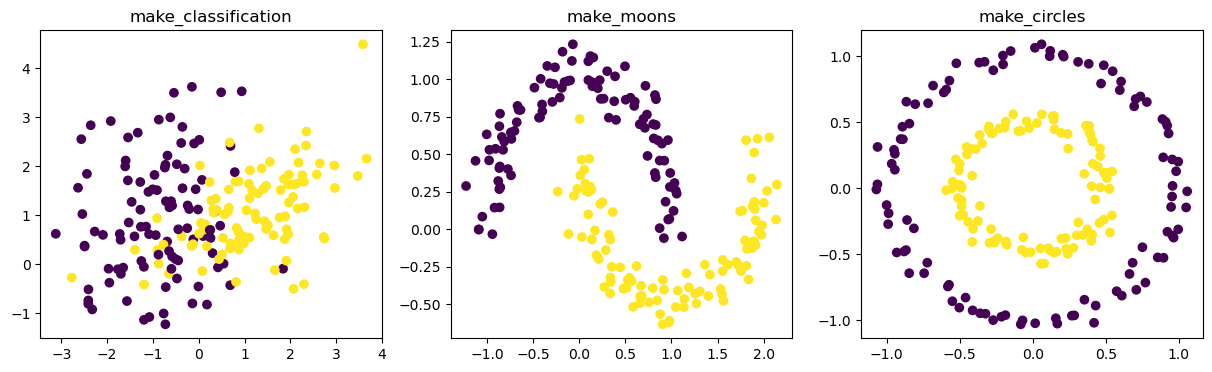

In [2]:
#linear datset
X_class, y_class = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

#moons dataset
X_moons, y_moons = make_moons(
    n_samples=200,
    noise=0.1,
    random_state=42
)

#circles dataset
X_circles, y_circles = make_circles(
    n_samples=200,
    noise=0.05,
    factor=0.5,
    random_state=42
)

#visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_class[:,0], X_class[:,1], c=y_class)
axes[0].set_title("make_classification")

axes[1].scatter(X_moons[:,0], X_moons[:,1], c=y_moons)
axes[1].set_title("make_moons")

axes[2].scatter(X_circles[:,0], X_circles[:,1], c=y_circles)
axes[2].set_title("make_circles")

plt.show()

In [3]:
#loading the datset
iris = load_iris()

X = iris.data       
y = iris.target     

In [4]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


# Model

In [5]:
#Building the classical model
def build_model(input_lenght=4, depth=3, n_class=2):

    model = Sequential()

    model.add(Dense(
        4,
        input_shape=(input_lenght,),
        activation='relu'
    ))

    for _ in range(depth - 1):

        model.add(Dense(
            4,
            activation='relu',
            use_bias=False
        ))

    model.add(Dense(
        n_class,
        activation='softmax',
        use_bias=False
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
model = build_model(depth=3, n_class=2)

/home/lenovo/anaconda3/envs/qiskit_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.count_params()

60

# Analysis

In [8]:
#taking two corresponding labels
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

In [9]:
#splitting in training and test
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

In [10]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sv = scaler.fit_transform(X_train_sv)
X_test_sv = scaler.transform(X_test_sv)

In [11]:
epochs = 100
n_runs = 50

all_accuracies = []
all_losses = []

for k in range(n_runs):

    model = build_model(depth=3, n_class=2)

    accuracies = []
    losses = []

    for i in range(epochs):

        history = model.fit(
            X_train_sv,
            y_train_sv,
            epochs=1,
            verbose=0
        )

        losses.append(history.history["loss"][0])

        y_pred = np.argmax(model.predict(X_test_sv, verbose=0), axis=1)
        acc = np.mean(y_pred == y_test_sv)

        accuracies.append(acc)

    all_accuracies.append(accuracies)
    all_losses.append(losses)

all_accuracies = np.array(all_accuracies)
all_losses = np.array(all_losses)

/home/lenovo/anaconda3/envs/qiskit_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


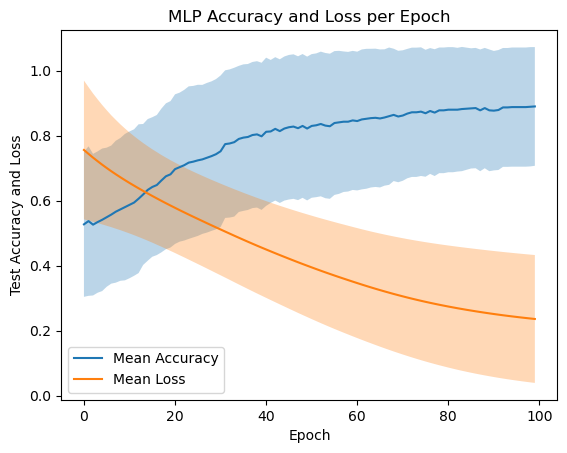

In [14]:
plt.figure()
plt.plot(np.mean(all_accuracies, axis=0), label="Mean Accuracy")
plt.fill_between(
    range(epochs),
    np.mean(all_accuracies, axis=0) - np.std(all_accuracies, axis=0),
    np.mean(all_accuracies, axis=0) + np.std(all_accuracies, axis=0),
    alpha=0.3
)
plt.plot(np.mean(all_losses, axis=0), label="Mean Loss")
plt.fill_between(
    range(epochs),
    np.mean(all_losses, axis=0) - np.std(all_losses, axis=0),
    np.mean(all_losses, axis=0) + np.std(all_losses, axis=0),
    alpha=0.3
)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy and Loss")
plt.title("MLP Accuracy and Loss per Epoch")
plt.legend()
plt.savefig("mlp_accuracy1.png")
plt.show()

# Fisher information 

In [15]:
params = model.trainable_variables

# total number of parameters
d = np.sum([tf.size(p).numpy() for p in params])

F = np.zeros((d, d))

N = len(X_train_sv)

for x, y in zip(X_train_sv, y_train_sv):

    x = tf.convert_to_tensor([x], dtype=tf.float32)
    y = tf.convert_to_tensor([y])

    with tf.GradientTape() as tape:

        preds = model(x, training=False)

        loss = tf.keras.losses.sparse_categorical_crossentropy(
            y,
            preds
        )

    grads = tape.gradient(loss, params)

    # flatten gradients
    g = np.concatenate([
        tf.reshape(grad, [-1]).numpy()
        for grad in grads
    ])

    # outer product
    F += np.outer(g, g)

# mean
F /= N

## Component analysis

In [16]:
t = F.trace()

eigvals, eigvecs = np.linalg.eigh(F)

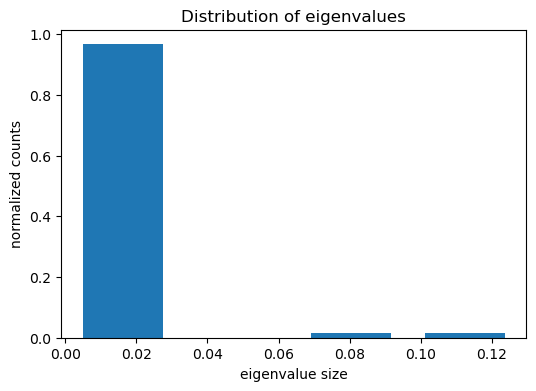

In [17]:
eigvals_abs = np.abs(eigvals)
weights = np.ones_like(eigvals) / len(eigvals)

plt.figure(figsize=(6,4))
plt.hist(eigvals_abs, bins=4, rwidth=0.7, weights=weights)
plt.xlabel(r"eigenvalue size")
plt.ylabel("normalized counts")
plt.title("Distribution of eigenvalues")
plt.savefig("hist_eig_classical1.png")
plt.show()

# PCA Analysis

From 4 features to the most informative 2

## Perform PCA 

In [18]:
iris = load_iris()
X = iris.data
y = iris.target

In [19]:
#taking two corresponding labels
mask = y!= 1

X_set_sevi = X[mask]
y_set_sevi = y[mask]

In [20]:
#splitting in training and test
X_train_sevi, X_test_sevi, y_train_sevi, y_test_sevi = train_test_split(
    X_set_sevi,
    y_set_sevi,
    test_size=0.2,
    random_state=42
)

In [21]:
#Trasforming the dataset from 4 features to 2 with pca
pca2 = PCA(n_components=2)
X_train_pca2 = pca2.fit_transform(X_train_sevi)
X_test_pca2 = pca2.transform(X_test_sevi)

In [22]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_pca2 = scaler.fit_transform(X_train_pca2)
X_test_pca2 = scaler.transform(X_test_pca2)

## New model 

In [23]:
def build_model2(input_lenght=2, depth=3, n_class=2):

    model = Sequential()

    model.add(Dense(
        4,
        input_shape=(input_lenght,),
        activation='relu'
    ))

    for _ in range(depth - 1):

        model.add(Dense(
            4,
            activation='relu',
            use_bias=False
        ))

    model.add(Dense(
        n_class,
        activation='softmax',
        use_bias=False
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [24]:
model2 = build_model2(depth=3, n_class=2)

/home/lenovo/anaconda3/envs/qiskit_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model2.count_params()

52

In [26]:
epochs = 100
n_runs = 50

all_accuracies_2 = []
all_losses_2 = []

for k in range(n_runs):

    model2 = build_model2(depth=3, n_class=2)

    accuracies = []
    losses = []

    for i in range(epochs):

        history = model2.fit(
            X_train_pca2,
            y_train_sv,
            epochs=1,
            verbose=0
        )

        losses.append(history.history["loss"][0])

        y_pred = np.argmax(model2.predict(X_test_pca2, verbose=0), axis=1)
        acc = np.mean(y_pred == y_test_sv)

        accuracies.append(acc)

    all_accuracies_2.append(accuracies)
    all_losses_2.append(losses)

all_accuracies_2 = np.array(all_accuracies_2)
all_losses_2 = np.array(all_losses_2)

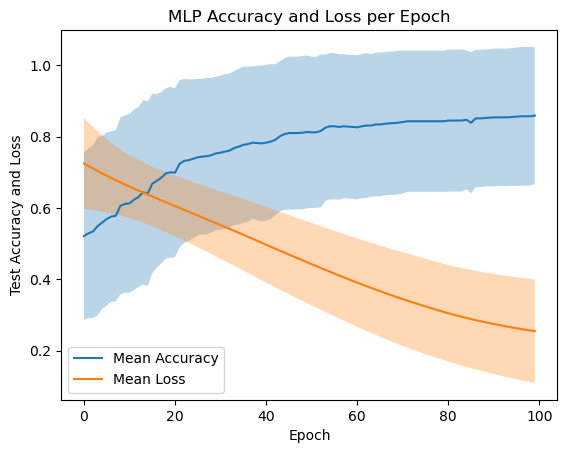

In [27]:
plt.figure()
plt.plot(np.mean(all_accuracies_2, axis=0), label="Mean Accuracy")
plt.fill_between(
    range(epochs),
    np.mean(all_accuracies_2, axis=0) - np.std(all_accuracies_2, axis=0),
    np.mean(all_accuracies_2, axis=0) + np.std(all_accuracies_2, axis=0),
    alpha=0.3
)
plt.plot(np.mean(all_losses_2, axis=0), label="Mean Loss")
plt.fill_between(
    range(epochs),
    np.mean(all_losses_2, axis=0) - np.std(all_losses_2, axis=0),
    np.mean(all_losses_2, axis=0) + np.std(all_losses_2, axis=0),
    alpha=0.3
)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy and Loss")
plt.title("MLP Accuracy and Loss per Epoch")
plt.legend()
plt.savefig("mlp_accuracy_pca21.png")
plt.show()

### Fisher information for pca model

In [28]:

params = model2.trainable_variables

# numero totale parametri
d2 = np.sum([tf.size(p).numpy() for p in params])

F2 = np.zeros((d2, d2))

N = len(X_train_pca2)

for x, y in zip(X_train_pca2, y_train_sv):

    x = tf.convert_to_tensor([x], dtype=tf.float32)
    y = tf.convert_to_tensor([y])

    with tf.GradientTape() as tape:

        preds = model2(x, training=False)

        loss = tf.keras.losses.sparse_categorical_crossentropy(
            y,
            preds
        )

    grads = tape.gradient(loss, params)

    # flatten gradienti
    g = np.concatenate([
        tf.reshape(grad, [-1]).numpy()
        for grad in grads
    ])

    # outer product
    F2 += np.outer(g, g)

# media
F2 /= N

In [29]:
t = F2.trace()

eigvals2, eigvecs2 = np.linalg.eigh(F2)

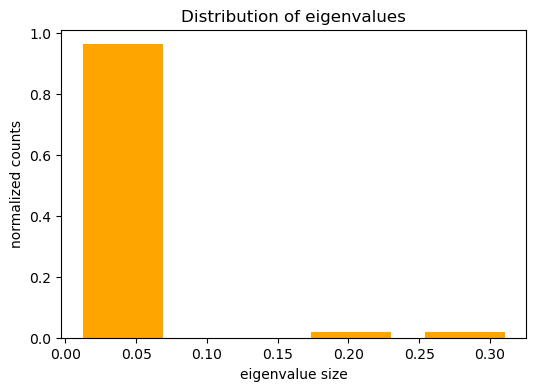

In [30]:
eigvals_abs2 = np.abs(eigvals2)
weights = np.ones_like(eigvals2) / len(eigvals2)

plt.figure(figsize=(6,4))
plt.hist(eigvals_abs2, bins=4, rwidth=0.7, weights=weights, color="orange")
plt.xlabel(r"eigenvalue size")
plt.ylabel("normalized counts")
plt.title("Distribution of eigenvalues")
plt.savefig("hist_eig_classical_pca21.png")
plt.show()

# Confront

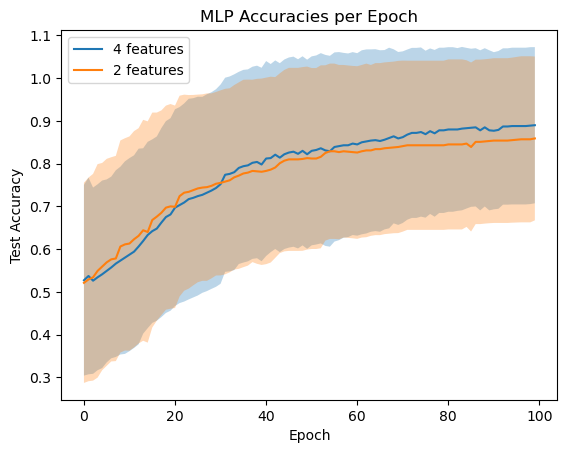

In [31]:
plt.figure()
plt.plot(np.mean(all_accuracies, axis=0), label="4 features")
plt.fill_between(
    range(epochs),
    np.mean(all_accuracies, axis=0) - np.std(all_accuracies, axis=0),
    np.mean(all_accuracies, axis=0) + np.std(all_accuracies, axis=0),
    alpha=0.3
)
plt.plot(np.mean(all_accuracies_2, axis=0), label="2 features")
plt.fill_between(
    range(epochs),
    np.mean(all_accuracies_2, axis=0) - np.std(all_accuracies_2, axis=0),
    np.mean(all_accuracies_2, axis=0) + np.std(all_accuracies_2, axis=0),
    alpha=0.3
)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("MLP Accuracies per Epoch")
plt.legend()
plt.savefig("confront_accuracy_pca21.png")
plt.show()

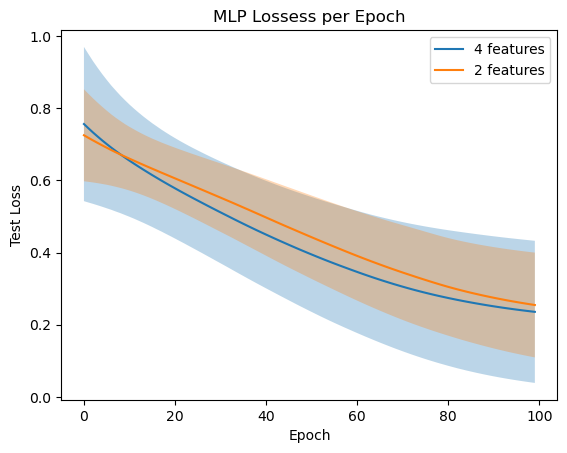

In [32]:
plt.figure()
plt.plot(np.mean(all_losses, axis=0), label="4 features")
plt.fill_between(
    range(epochs),
    np.mean(all_losses, axis=0) - np.std(all_losses, axis=0),
    np.mean(all_losses, axis=0) + np.std(all_losses, axis=0),
    alpha=0.3
)
plt.plot(np.mean(all_losses_2, axis=0), label="2 features")
plt.fill_between(
    range(epochs),
    np.mean(all_losses_2, axis=0) - np.std(all_losses_2, axis=0),
    np.mean(all_losses_2, axis=0) + np.std(all_losses_2, axis=0),
    alpha=0.3
)
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("MLP Lossess per Epoch")
plt.legend()
plt.savefig("confront_loss_pca21.png")
plt.show()

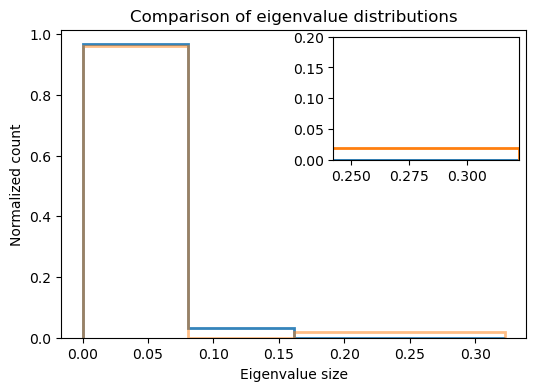

In [33]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

bins = np.linspace(
    min(eigvals_abs.min(), eigvals_abs2.min()),
    max(eigvals_abs.max(), eigvals_abs2.max()),
    5
)

weights1 = np.ones_like(eigvals_abs) / len(eigvals_abs)
weights2 = np.ones_like(eigvals_abs2) / len(eigvals_abs2)

fig, ax = plt.subplots(figsize=(6,4))

ax.hist(
    eigvals_abs,
    bins=bins,
    weights=weights1,
    histtype="step",
    alpha=0.9,
    linewidth=2,
    label="4 features"
)

ax.hist(
    eigvals_abs2,
    bins=bins,
    weights=weights2,
    histtype="step",
    alpha=0.5,
    linewidth=2,
    label="2 features"
)

ax.set_xlabel("Eigenvalue size")
ax.set_ylabel("Normalized count")
ax.set_title("Comparison of eigenvalue distributions")
ax.legend()

# ----- Zoom sull'ultimo bin -----
axins = inset_axes(ax, width="40%", height="40%", loc="upper right")

axins.hist(
    eigvals_abs,
    bins=bins,
    weights=weights1,
    histtype="step",
    linewidth=2
)

axins.hist(
    eigvals_abs2,
    bins=bins,
    weights=weights2,
    histtype="step",
    linewidth=2
)

axins.set_xlim(bins[-2], bins[-1])

axins.set_ylim(0, 0.2)

plt.savefig('confront_eigenvalues1.png')

plt.show()